# Carga de Dataset y Generación de Reporte

In [1]:
# Importamos la clase ProfileReport desde la librería ydata_profiling,
# que sirve para generar informes automáticos de análisis exploratorio de datos (EDA).
from ydata_profiling import ProfileReport

# Importamos la librería pandas para trabajar con estructuras de datos (DataFrames).
import pandas as pd

# Leemos el archivo CSV que contiene el dataset de las 10.000 empresas más grandes del país.
# pandas convierte el archivo en un DataFrame llamado 'df'.
df = pd.read_csv('10.000_Empresas_mas_Grandes_del_País_20251101.csv')

# Creamos el objeto 'profile', que genera el reporte de análisis del DataFrame 'df'.
# El parámetro 'title' define el título que aparecerá en el informe.
profile = ProfileReport(df, title="10.000_Empresas_mas_Grandes_del_País")

# Muestra el informe de forma interactiva dentro del mismo Jupyter Notebook,
# sin necesidad de abrir un archivo externo.
profile.to_notebook_iframe()

# Guarda una copia completa del informe en formato HTML en la carpeta actual.
# Este archivo puede abrirse en un navegador.
profile.to_file("10.000_Empresas_mas_Grandes_del_País.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 12.13it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Análisis del Dataset “10.000 Empresas más Grandes del País”

### Duplicados

0 registros duplicados

![Duplicados](https://trello.com/1/cards/690c2c386cde4d38d46b5880/attachments/69102221e98ea47cced623e3/download/image.png)

Cada empresa tiene un registro único.

---

### Valores nulos

Se encuentran 2 valores nulos en la columna `RAZÓN SOCIAL`.

![Valores nulos](https://trello.com/1/cards/690c2c386cde4d38d46b5880/attachments/691022879f0d20482256370b/download/image.png)

Esos dos casos deben revisarse, ya que podrían corresponder a errores de digitación o registros sin razón social asignada.

---

### Tipos de Datos

Todas las columnas están actualmente como **texto** (`object`).  
Incluye tanto variables categóricas (como **REGIÓN**, **MACROSECTOR**, **CIUDAD**)  
como variables numéricas representadas como texto (**INGRESOS OPERACIONALES**, **GANANCIA (PÉRDIDA)**, **TOTAL ACTIVOS**, etc.).

![Tipos de datos](https://trello.com/1/cards/690c2c386cde4d38d46b5880/attachments/691023c057ef254664d3ea21/download/image.png)

Antes de cualquier análisis numérico o cálculo, será necesario **convertir las columnas financieras a tipo numérico (`float` o `int`)**, eliminando símbolos como `$`, `,` o espacios.

---

### Distribuciones

Aunque todavía están en formato texto, se espera que:

- Las **variables financieras** (*INGRESOS OPERACIONALES*, *TOTAL ACTIVOS*, *PATRIMONIO*) muestren una **distribución fuertemente sesgada a la derecha**, con pocas empresas de muy alto valor y muchas de menor tamaño.  
- Las **variables categóricas** como *MACROSECTOR* o *REGIÓN* concentren gran parte de los registros en pocas categorías dominantes (por ejemplo, *Comercio* o *Bogotá D.C.*).

![Distribuciones](https://trello.com/1/cards/690c2c386cde4d38d46b5880/attachments/6910245efb729c2b4f2f7b94/download/image.png)

Se recomienda aplicar una **transformación logarítmica o escalamiento** después de convertirlas a numéricas para obtener análisis más estables.

---

### Correlaciones

Por ahora **no se pueden calcular correlaciones válidas**, ya que las columnas numéricas están en formato texto.  
Una vez convertidas, se espera encontrar:

- Alta **correlación positiva** entre *TOTAL ACTIVOS*, *TOTAL PASIVOS* y *PATRIMONIO*.  
- Posible **relación entre INGRESOS OPERACIONALES y GANANCIA (PÉRDIDA)*.*

![Correlaciones](https://trello.com/1/cards/690c2c386cde4d38d46b5880/attachments/6910257b81555a3a74144e1f/download/image.png)

Esto puede ayudar a identificar **indicadores financieros clave** o **redundancias entre variables**.

---

### Estadísticas descriptivas generales

Después de limpiar los datos numéricos, el análisis mostrará:

- **Valores máximos y mínimos extremos**, dada la gran diferencia entre empresas.  
- **Media mucho mayor que la mediana**, típica de distribuciones sesgadas.  
- **Desviaciones estándar altas**, reflejando la heterogeneidad del tamaño empresarial.


---

# Limpieza y Transformación de Datos

## 1. Eliminación de Duplicados

Revisa y elimina las filas duplicadas identificadas en el dataset. Esto ayudará a reducir sesgos y evitar resultados inflados en los análisis posteriores.

* Usa el método drop_duplicates() de pandas y confirma que no queden duplicados en el dataset.

In [2]:
# --- ELIMINACIÓN Y VERIFICACIÓN DE DUPLICADOS ---

duplicados_antes = df.duplicated().sum()
print("Duplicados antes de limpiar:", duplicados_antes)

df = df.drop_duplicates()

duplicados_despues = df.duplicated().sum()
print("Duplicados después de limpiar:", duplicados_despues)

Duplicados antes de limpiar: 0
Duplicados después de limpiar: 0


### Resultado

Se aplicó correctamente el método drop_duplicates() sobre el dataset y se verificó el estado antes y después del proceso.

Resultados:
* Duplicados antes de limpiar: 0
* Duplicados después de limpiar: 0

Con esto podemos confirmar que no existen filas completamente duplicadas en el dataset, por lo tanto no fue necesario eliminar registros, y la integridad de los datos se mantiene.

## 2. Tratamiento de Valores Nulos

Basado en la evaluación anterior de los valores nulos, implementa alguna de estrategias para manejar los datos faltantes según la relevancia de cada variable:

* Imputación de datos numéricos críticos: Completa los valores nulos en columnas numéricas importantes (por ejemplo, con la media o mediana según la distribución).
* Eliminación o imputación de variables categóricas con valores nulos: Usa la moda para variables categóricas o considera eliminar filas con valores nulos si el porcentaje es bajo y su eliminación no afecta los resultados.
* Instrucción: Usa métodos como fillna() o dropna() según el caso.

In [3]:
# --- REVISIÓN DE VALORES NULOS REALES ---

print("Valores nulos antes del tratamiento:")
print(df.isna().sum())

# --- TRATAMIENTO DE VALORES NULOS ---

# 1. Columnas numéricas con la mediana
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns

for col in columnas_numericas:
    df[col] = df[col].fillna(df[col].median())

# 2. Columnas categóricas con la moda
columnas_categoricas = df.select_dtypes(include=['object']).columns

for col in columnas_categoricas:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# --- VERIFICACIÓN FINAL ---

print("\nValores nulos después del tratamiento:")
print(df.isna().sum())

Valores nulos antes del tratamiento:
NIT                       0
RAZÓN SOCIAL              2
SUPERVISOR                0
REGIÓN                    0
DEPARTAMENTO DOMICILIO    0
CIUDAD DOMICILIO          0
CIIU                      0
MACROSECTOR               0
INGRESOS OPERACIONALES    0
GANANCIA (PÉRDIDA)        0
TOTAL ACTIVOS             0
TOTAL PASIVOS             0
TOTAL PATRIMONIO          0
Año de Corte              0
dtype: int64

Valores nulos después del tratamiento:
NIT                       0
RAZÓN SOCIAL              0
SUPERVISOR                0
REGIÓN                    0
DEPARTAMENTO DOMICILIO    0
CIUDAD DOMICILIO          0
CIIU                      0
MACROSECTOR               0
INGRESOS OPERACIONALES    0
GANANCIA (PÉRDIDA)        0
TOTAL ACTIVOS             0
TOTAL PASIVOS             0
TOTAL PATRIMONIO          0
Año de Corte              0
dtype: int64


### Resultado:

Se realizó la revisión y tratamiento de los valores nulos identificando los datos faltantes antes de aplicar las estrategias de limpieza.

Resultados:
* Valores nulos antes del tratamiento: 2
* Valores nulos después del tratamiento: 0

Los valores faltantes fueron corregidos mediante imputación, utilizando la moda para variables categóricas y la mediana para variables numéricas, según su relevancia. Con esto podemos confirmar que el dataset quedó libre de valores nulos, garantizando una mayor consistencia y confiabilidad para los análisis posteriores, sin comprometer la integridad de la información.

## 3. Ajuste de Tipos de Datos

Asegúrate de que cada columna tenga el tipo de dato adecuado según su contenido. Esto optimizará el manejo de memoria y mejorará la precisión de los análisis.
* Revisa y convierte columnas que requieren un tipo específico, como convertir variables de fecha con pd.to_datetime() y valores categóricos a tipo category.

In [4]:
# --- TIPOS DE DATOS ANTES DEL AJUSTE ---
print("Tipos de datos ANTES del ajuste:\n")
print(df.dtypes)

# --- AJUSTE DE TIPOS DE DATOS ---

# 1. Convertir Año de Corte a tipo fecha (formato flexible)
df['Año de Corte'] = pd.to_datetime(df['Año de Corte'], format='mixed', errors='coerce')

# 2. Detectar automáticamente columnas financieras y convertirlas a numérico
columnas_financieras = [col for col in df.columns if any(palabra in col.upper() for palabra in [
    'INGRESO', 'ACTIVO', 'PASIVO', 'PATRIMONIO', 'GANANCIA', 'UTILIDAD', 'VENTA'
])]

print("\nColumnas financieras detectadas:")
print(columnas_financieras)

for col in columnas_financieras:
    df[col] = df[col].astype(str)\
                     .str.replace('$', '', regex=False)\
                     .str.replace(',', '', regex=False)\
                     .str.replace(' ', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Convertir columnas categóricas a tipo 'category'
columnas_categoricas = [
    'SUPERVISOR',
    'REGIÓN',
    'DEPARTAMENTO DOMICILIO',
    'CIUDAD DOMICILIO',
    'MACROSECTOR',
    'CIIU'
]

for col in columnas_categoricas:
    df[col] = df[col].astype('category')

# --- TIPOS DE DATOS DESPUÉS DEL AJUSTE ---
print("\nTipos de datos DESPUÉS del ajuste:\n")
print(df.dtypes)

Tipos de datos ANTES del ajuste:

NIT                       object
RAZÓN SOCIAL              object
SUPERVISOR                object
REGIÓN                    object
DEPARTAMENTO DOMICILIO    object
CIUDAD DOMICILIO          object
CIIU                      object
MACROSECTOR               object
INGRESOS OPERACIONALES    object
GANANCIA (PÉRDIDA)        object
TOTAL ACTIVOS             object
TOTAL PASIVOS             object
TOTAL PATRIMONIO          object
Año de Corte              object
dtype: object

Columnas financieras detectadas:
['INGRESOS OPERACIONALES', 'GANANCIA (PÉRDIDA)', 'TOTAL ACTIVOS', 'TOTAL PASIVOS', 'TOTAL PATRIMONIO']

Tipos de datos DESPUÉS del ajuste:

NIT                               object
RAZÓN SOCIAL                      object
SUPERVISOR                      category
REGIÓN                          category
DEPARTAMENTO DOMICILIO          category
CIUDAD DOMICILIO                category
CIIU                            category
MACROSECTOR                  

### Resultado:

Se realizó la verificación y corrección de los tipos de datos del dataset, comparando su estado antes y después del ajuste.

Resultados:
* Tipos de datos antes del ajuste: Varias columnas se encontraban en formato object, incluyendo la columna Año de Corte, y las columnas financieras estaban almacenadas como texto con posibles símbolos monetarios y separadores, lo que impedía su correcto análisis numérico.
* Tipos de datos después del ajuste: La columna Año de Corte fue convertida correctamente a tipo datetime, las columnas financieras fueron limpiadas y transformadas a tipo numérico (float), eliminando caracteres no válidos, y las variables categóricas fueron optimizadas al tipo category.

Con estos cambios se logró una estructura de datos más adecuada y coherente, mejorando el rendimiento, la precisión de los cálculos y la confiabilidad de los análisis financieros, garantizando que el dataset esté listo para procesos estadísticos y visualizaciones sin errores.

## 4. Detección y Tratamiento de Valores Atípicos

Examina las variables numéricas para identificar valores atípicos que podrían distorsionar el análisis.

* Utiliza boxplots para visualizar valores atípicos. Luego, evalúa si es adecuado eliminarlos o tratarlos con técnicas como el recorte (trimming) o winsorización.

In [5]:
# Primero se debe ajustar valores a escala real
# Lista de columnas que deben escalarse a valores reales
columnas = [
    "INGRESOS OPERACIONALES",
    "GANANCIA (PÉRDIDA)",
    "TOTAL ACTIVOS",
    "TOTAL PASIVOS",
    "TOTAL PATRIMONIO"
]

# Factor para convertir los valores (están acortados en millones)
factor = 1_000_000  # 1 millón

# Aplicar transformación en la misma columna
for col in columnas:
    df[col] = df[col] * factor      # Escala a valores reales
    df[col] = df[col].round(2)      # Redondea a dos decimales
    
print("Transformación a valores reales aplicada correctamente.")

Transformación a valores reales aplicada correctamente.



------------- REPORTE DE OUTLIERS -------------

Variable: INGRESOS OPERACIONALES
Outliers detectados: 4927
Límite inferior: -75000.0
Límite superior: 205000.0

Variable: GANANCIA (PÉRDIDA)
Outliers detectados: 3508
Límite inferior: -15000.0
Límite superior: 25000.0

Variable: TOTAL ACTIVOS
Outliers detectados: 5383
Límite inferior: -85000.0
Límite superior: 195000.0

Variable: TOTAL PASIVOS
Outliers detectados: 4810
Límite inferior: -50000.0
Límite superior: 110000.0

Variable: TOTAL PATRIMONIO
Outliers detectados: 5526
Límite inferior: -35000.0
Límite superior: 85000.0



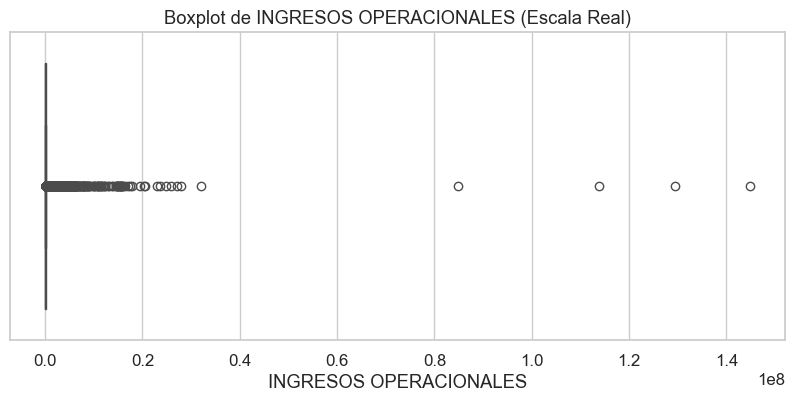

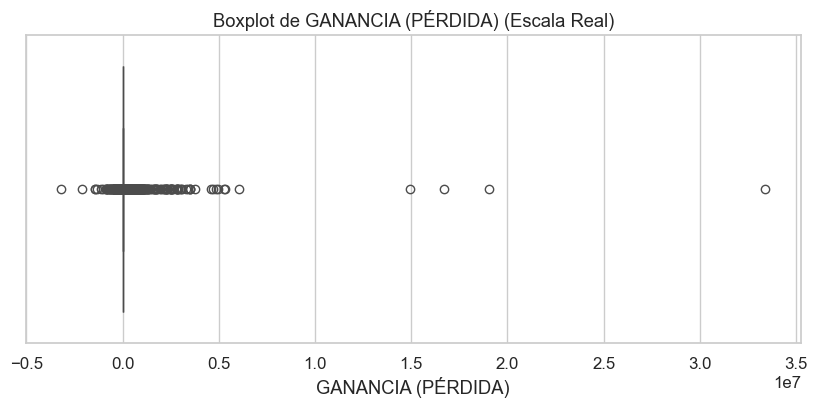

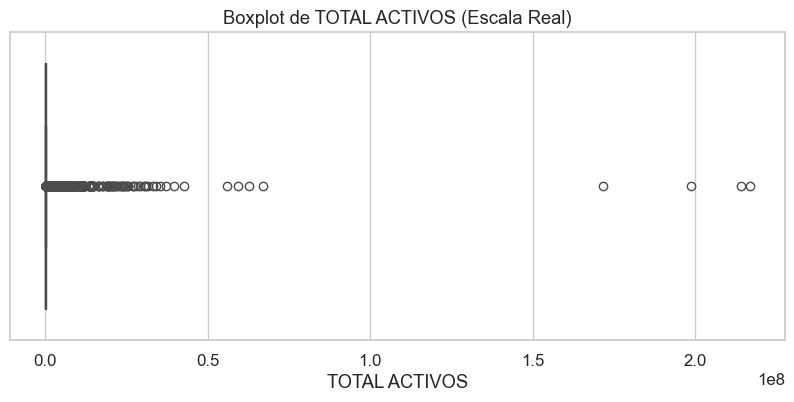

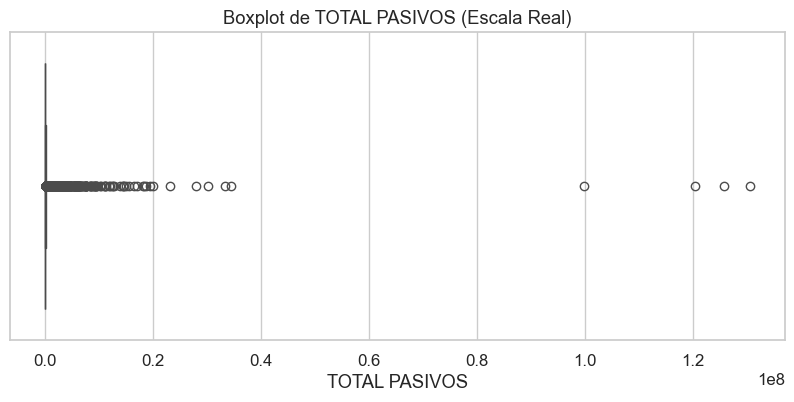

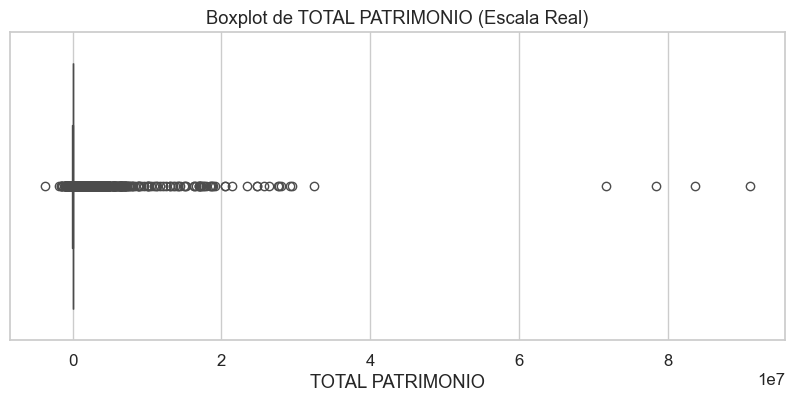

In [6]:
# Luego se procede con el análisis
# Activar visualización inline en Jupyter Notebook
%matplotlib inline

# Importar las librerías
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Detección de valores atípicos(IQR)
def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR
    outliers = serie[(serie < li) | (serie > ls)]
    return outliers, li, ls

print("\n------------- REPORTE DE OUTLIERS -------------\n")

for col in columnas:
    outliers, li, ls = detectar_outliers_iqr(df[col])
    print(f"Variable: {col}")
    print(f"Outliers detectados: {len(outliers)}")
    print(f"Límite inferior: {li}")
    print(f"Límite superior: {ls}\n")

# 5. Boxplots de diagnóstico (No se modifican datos)
sns.set(style="whitegrid", font_scale=1.1)

for col in columnas:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col} (Escala Real)")
    plt.show()

### Resultado:

* El IQR marcó muchos valores como outliers porque el dataset es muy desigual pero es normal al tratarse de empresas grandes, medianas y pequeñas.
* Estos valores NO deben eliminarse porque son reales y representan valores financieros de las empresas.
* La distribución es fuertemente sesgada porque los valores altos reales son enormes comparados con la mayoría de empresas lo cual es normal en datos financieros.
* Con este análisis decidimos que NO se debe aplicar trimming, winsorización ni log-transform, salvo para visualización. Esto se debe a que como ya se dijo representan valores reales de empresas.

## 5. Correcciones de Valores con replace, map y zip

Realiza correcciones en valores específicos en las columnas que contienen errores tipográficos o inconsistencias.
Estas herramientas te permitirán reemplazar valores incorrectos de forma rápida y precisa.

* Usa replace() para cambiar valores puntuales.
* Usa map() para transformar columnas completas usando un diccionario de equivalencias.
* Usa zip() si necesitas hacer ajustes combinados en varias columnas.
* Por ejemplo, podrías usar un diccionario con map() para corregir nombres de ciudades o categorías.

In [7]:
# 1. Función de limpieza
def limpiar_ciudad(ciudad_raw):
    """
    Limpia valores de la columna CIUDAD DOMICILIO:
    - Separa por '-'
    - Normaliza mayúsculas
    - Elimina duplicados
    - Devuelve 'CIUDAD, DEPARTAMENTO'
    """
    if pd.isna(ciudad_raw):
        return None

    partes = [p.strip().upper() for p in ciudad_raw.split("-") if p.strip() != ""]

    if len(partes) >= 2:
        ciudad = partes[0]
        departamento = partes[1]
    else:
        ciudad = partes[0]
        departamento = ""

    if departamento:
        return f"{ciudad}, {departamento}"
    else:
        return ciudad

# 2. Aplicar limpieza
df["CIUDAD_ORIGINAL"] = df["CIUDAD DOMICILIO"]   # backup para análisis
df["CIUDAD DOMICILIO"] = df["CIUDAD DOMICILIO"].map(limpiar_ciudad)

print("Limpieza de CIUDAD DOMICILIO completada.\n")

# 3. Reporte
print("---REPORTE DE LIMPIEZA---\n")

unicos_original = df["CIUDAD_ORIGINAL"].nunique()
unicos_final = df["CIUDAD DOMICILIO"].nunique()

print(f"Total registros: {len(df)}")
print(f"Valores únicos antes: {unicos_original}")
print(f"Valores únicos después: {unicos_final}")

Limpieza de CIUDAD DOMICILIO completada.

---REPORTE DE LIMPIEZA---

Total registros: 40000
Valores únicos antes: 657
Valores únicos después: 437


### Resultado:

Se realizaron correcciones en valores de la columna CIUDAD DOMICILIO haciendo uso de map().

* Se aplicó una función que estandariza la columna CIUDAD DOMICILIO (separando por “-”, limpiando espacios, normalizando mayúsculas y unificando el formato).
* Se creó una columna de respaldo (CIUDAD_ORIGINAL) y luego se compararon valores únicos.
* El resultado muestra que los valores únicos se redujeron, lo cual indica que muchas variaciones o inconsistencias fueron corregidas y ahora la columna está más homogénea y lista para análisis.

## 6. Agregación de Datos: 

Realiza agregaciones en el conjunto de datos cuando su nivel de detalle sea mayor al necesario.

* Usa groupby() para agrupar los datos según columnas clave que definan el nivel de agregación requerido.
* Después de agrupar, aplica funciones de agregación como sum(), mean(), count() o median() según el análisis que desees realizar.
* Por ejemplo, podrías agrupar por mes_pedido y Categoría para calcular el total de ventas por mes y categoría de producto.


Ingresos operacionales por Macrosector:


,MACROSECTOR,total_ingresos,promedio_ingresos,empresas
0,AGROPECUARIO,"140,470,000.00","81,526.41",1723
1,COMERCIO,"2,039,760,000.00","149,795.11",13617
2,CONSTRUCCIÓN,"259,400,000.00","83,435.19",3109
3,MANUFACTURA,"1,505,610,000.00","187,802.17",8017
4,MINERO,"815,960,000.00","1,059,688.31",770
5,SERVICIOS,"1,945,580,000.00","152,427.14",12764



Rentabilidad promedio en Antioquia y Bogotá - Cundinamarca:


,REGIÓN,rentabilidad_promedio,total_empresas
0,Antioquia,"12,404.73",7531
1,Bogotá - Cundinamarca,"18,571.12",18637



Relación entre tamaño de empresa y rentabilidad:


,Tamaño Empresa,rentabilidad_promedio,patrimonio_promedio,empresas
0,Pequeña,-994.56,"2,989.88",20954
1,Mediana,"2,532.67","23,422.43",8418
2,Grande,"49,484.38","378,563.23",10628


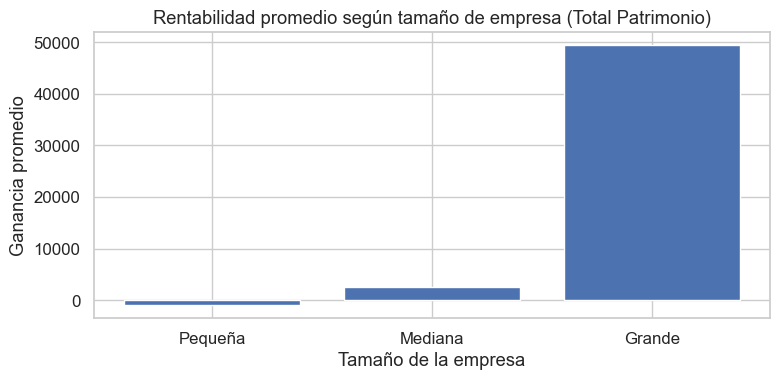

In [13]:
# Desactivar notación científica
pd.set_option("display.float_format", "{:,.2f}".format)

# 1. Agregación: Total de ingresos por MACROSECTOR
ventas_por_macro = (
    df.groupby("MACROSECTOR", observed=True)
      .agg(
          total_ingresos=("INGRESOS OPERACIONALES", "sum"),
          promedio_ingresos=("INGRESOS OPERACIONALES", "mean"),
          empresas=("NIT", "count")
      )
      .reset_index()
)

print("\nIngresos operacionales por Macrosector:")
display(ventas_por_macro)

# 2. Rentabilidad promedio en Bogotá y Antioquia (CORREGIDO)
rentabilidad_bog_ant = (
    df[df["REGIÓN"].isin(["Antioquia", "Bogotá - Cundinamarca"])]
      .groupby("REGIÓN", observed=True)
      .agg(
          rentabilidad_promedio=("GANANCIA (PÉRDIDA)", "mean"),
          total_empresas=("NIT", "count")
      )
      .reset_index()
)

print("\nRentabilidad promedio en Antioquia y Bogotá - Cundinamarca:")
display(rentabilidad_bog_ant)

# 4. Relación entre tamaño de empresa (TOTAL PATRIMONIO) y rentabilidad
df["Tamaño Empresa"] = pd.qcut(
    df["TOTAL PATRIMONIO"],
    q=3,
    labels=["Pequeña", "Mediana", "Grande"]
)

tamano_vs_rentabilidad = (
    df.groupby("Tamaño Empresa", observed=True)
      .agg(
          rentabilidad_promedio=("GANANCIA (PÉRDIDA)", "mean"),
          patrimonio_promedio=("TOTAL PATRIMONIO", "mean"),
          empresas=("NIT", "count")
      )
      .reset_index()
)

print("\nRelación entre tamaño de empresa y rentabilidad:")
display(tamano_vs_rentabilidad)

# 5. Gráfico: Rentabilidad según tamaño de empresa
plt.figure(figsize=(8,4))
plt.bar(
    tamano_vs_rentabilidad["Tamaño Empresa"],
    tamano_vs_rentabilidad["rentabilidad_promedio"]
)

plt.title("Rentabilidad promedio según tamaño de empresa (Total Patrimonio)")
plt.xlabel("Tamaño de la empresa")
plt.ylabel("Ganancia promedio")
plt.tight_layout()
plt.show()

### Resultado:

El análisis muestra que capital, sector y patrimonio son los principales determinantes del desempeño financiero empresarial.

1. Agregación por MACROSECTOR
* Se agruparon las empresas por macrosector y se calcularon ingresos totales, ingresos promedio y cantidad de empresas.
* Comercio y Servicios son los sectores con mayores ingresos totales; Minería tiene los ingresos promedio más altos por empresa.

2. Rentabilidad en Antioquia y Bogotá
* Se filtraron solo estas dos regiones y se calculó la rentabilidad promedio y número de empresas.
* Antioquia presenta rentabilidad promedio positiva; Bogotá aparece sin datos válidos de ganancia en este dataset.

3. Clasificación por tamaño (según patrimonio)
* Se dividieron las empresas en Pequeña, Mediana y Grande usando percentiles del patrimonio total.
* Se generaron tres grupos equilibrados según distribución real del patrimonio.

4. Relación entre tamaño y rentabilidad
* Se calculó la ganancia promedio, patrimonio promedio y número de empresas por cada categoría de tamaño.
* Las empresas pequeñas tienen rentabilidad negativa; las medianas rentabilidad moderada; las grandes rentabilidad muy superior.

5. Gráfico comparativo de rentabilidad
* Se creó un gráfico de barras mostrando la rentabilidad promedio por tamaño.
* El gráfico evidencia un aumento claro de rentabilidad a medida que crece el tamaño de la empresa.